# Wilson-Cowan Pairwise Model

---
## **1. Theoretical Introduction**

### **1.1. Wilson-Cowan Model**
The Wilson-Cowan model describes the dynamics of excitatory (E) and inhibitory (I) neural populations with pairwise interactions.

#### **Model Equations:**
- **Excitatory Population:**
  $$
  \tau_E \frac{dE_i}{dt} = -E_i + S\left(c_{EE} E_i - c_{IE} I_i + P + K \sum_{j} M_{ij} E_j\right)
  $$

- **Inhibitory Population:**
  $$
  \tau_I \frac{dI_i}{dt} = -I_i + S\left(c_{EI} E_i - c_{II} I_i + Q\right)
  $$

#### **Sigmoid Function:**
$$
S(v) = \frac{1}{1 + e^{-a v}}
$$

---
## **2. Initial Setup**
We import the functions already defined in the `Scripts` folder.


In [ ]:
import sys
import os
sys.path.append('../')  # Ensure Python can find the 'Scripts' folder

#from Scripts.parameters import *
from Scripts.parameters_random import *
from Scripts.dynamics import *
from Scripts.simulation import *
from Scripts.oscillation_detection import *
from Scripts.metrics import *
from Scripts.visualization import *

# Parameter ranges for oscillation detection
P_values = np.linspace(1.0, 10.0, 20)
K_values = np.linspace(0.0, 1.0, 20)
K3_values = np.linspace(0.0, 1.0, 20)

print("Functions loaded successfully.")

Stable Rank: 1.50
Nuclear Rank: 2.00
Effective Rank (Energy Ratio 95%): 3
Stable Rank: 1.50
Nuclear Rank: 2.00
Effective Rank (Energy Ratio 95%): 3
Functions loaded successfully.


---
## **3. Basic Simulation and Signal Plotting**
We simulate the model with default parameters and visualize the signals.


Total timesteps: 10000
Analysis timesteps: 9001

Node 0:
  E: mean=0.2643, std=0.1120, range=[0.0930, 0.5537]
  I: mean=0.4843, std=0.0584, range=[0.3829, 0.6386]

Node 1:
  E: mean=0.1834, std=0.0798, range=[0.0564, 0.4231]
  I: mean=0.4589, std=0.0546, range=[0.3655, 0.6374]

Node 2:
  E: mean=0.1867, std=0.0889, range=[0.0540, 0.4718]
  I: mean=0.4657, std=0.0606, range=[0.3680, 0.6499]


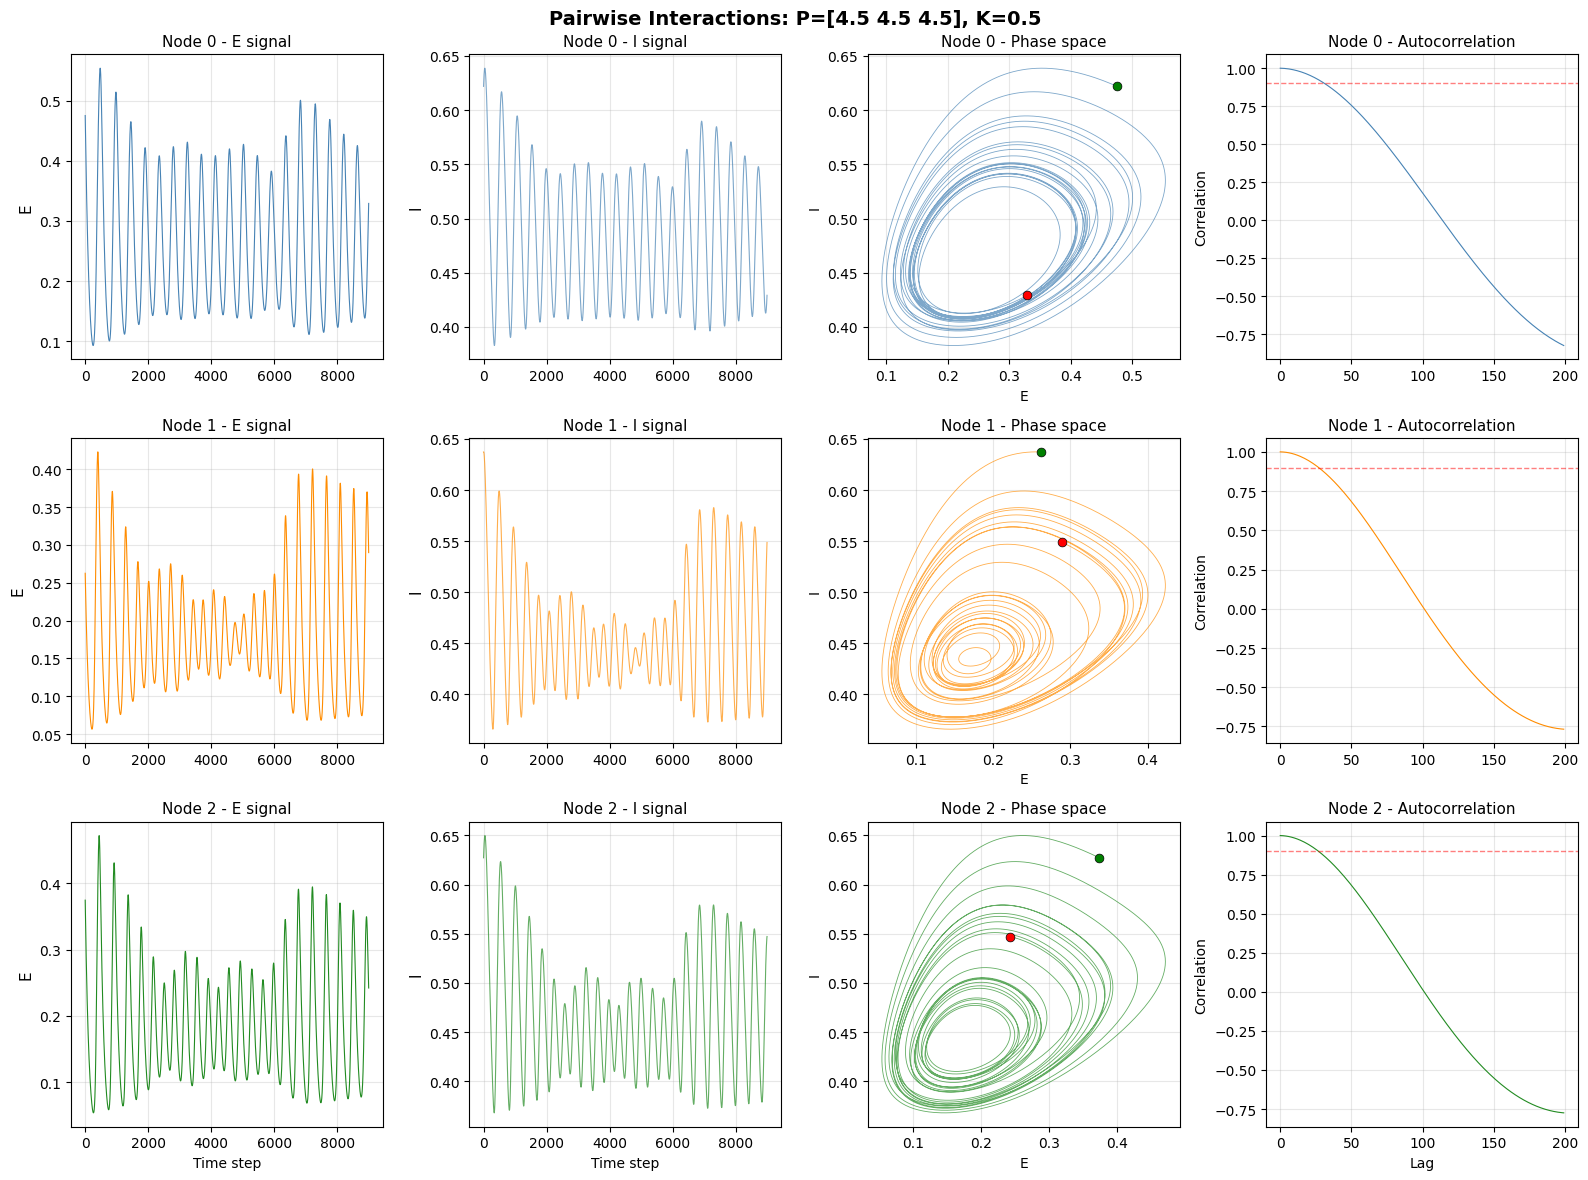

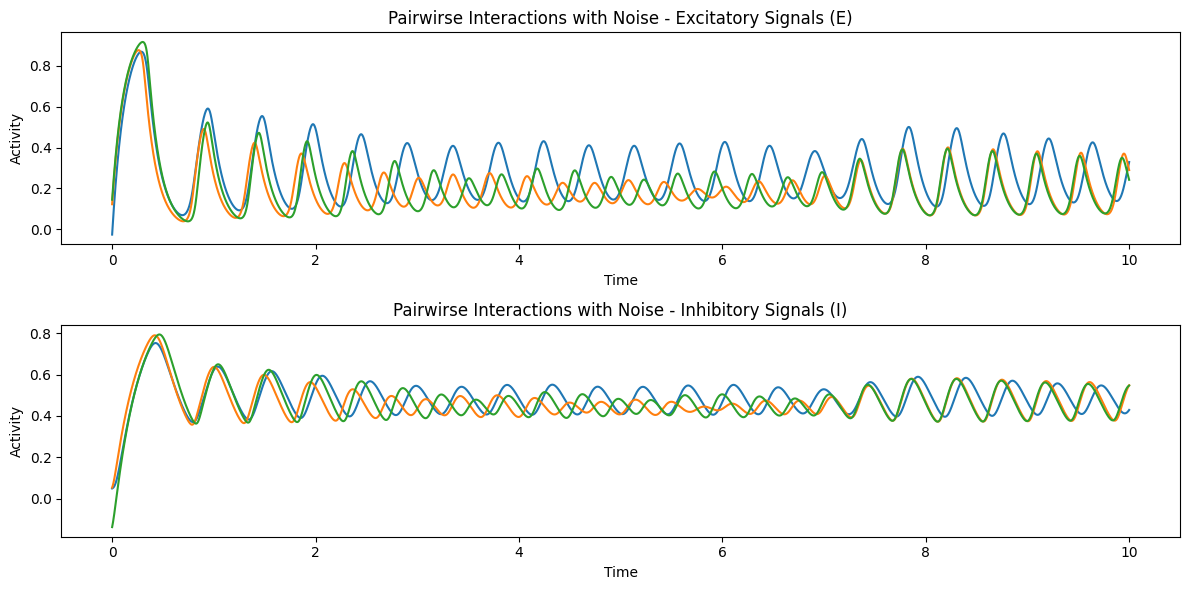

In [16]:
# Simulation parameters
#P_sim = np.array([5.0, 3.0, 4.0])  # P por nodo
P_sim = np.array([4.5, 4.5, 4.5])  # P por nodo
K_sim = 0.5

# Initial state
state0 = 0.1 * np.random.randn(2 * N_nodes)
T=10

# Simulation using the existing function
t, states = simulate_wc(state0, P_sim, K_sim, M, T, dt)
#t, states = simulate_wc(state0, K_sim, M, T=T, dt=dt)

# Extract signals
E = states[:, :N_nodes]
I = states[:, N_nodes:]

# Visualization using the existing function
plot_detailed_signals(t, states, N_nodes, P_sim=P_sim, K_sim=K_sim, title="Pairwise Interactions")
plot_signals(t, E, I, title="Pairwirse Interactions with Noise")


---
## **4. Oscillation Detection in $(P \times K$) Space**
We perform a parameter sweep to detect oscillations in the $(P \times K$) space.


In [17]:
# Matrix to store oscillation detection
oscillation_map = np.zeros((len(P_values), len(K_values)), dtype=int)

# Matrices to store metrics with noise
TC_map = np.zeros((len(P_values), len(K_values)))
DTC_map = np.zeros((len(P_values), len(K_values)))
Cumulant_map = np.zeros((len(P_values), len(K_values)))
PowerCorr_map = np.zeros((len(P_values), len(K_values)))
Entropy_map = np.zeros((len(P_values), len(K_values)))  # Nueva métrica
Entropy_map_skew = np.zeros((len(P_values), len(K3_values)))  # Nueva métrica
Entropy_map_kurt = np.zeros((len(P_values), len(K3_values)))  # Nueva métrica

#initial state random fixed
seed = 42
rng = np.random.default_rng(seed)
state0 = 0.1 * rng.standard_normal(2 * N_nodes)
#deleting the firts 20% of the signal
start_idx = int(0.2 * len(t))
T=20


for i, P_val in enumerate(P_values):
    for j, K_val in enumerate(K_values):
        # Simulation using the existing function
        P_vec = np.array([P_val, P_val, P_val])
        t, states = simulate_wc(state0, P_vec, K_val, M, T, dt)

        E_node = states[start_idx:, :N_nodes]
        I_node = states[start_idx:, N_nodes:]

        # Oscillation detection using the existing function
        is_lc1, _, _, _ = detect_limit_cycle_poincare(E_node[:, 0], I_node[:, 0], dt, threshold_ratio=0.05, period_cv_threshold=0.05)
        is_lc2, _, _, _ = detect_limit_cycle_poincare(E_node[:, 0], I_node[:, 0], dt, threshold_ratio=0.05, period_cv_threshold=0.05)
        is_lc3, _, _, _ = detect_limit_cycle_poincare(E_node[:, 0], I_node[:, 0], dt, threshold_ratio=0.05, period_cv_threshold=0.05)
        oscillation_map[i, j] = int((is_lc1==True) and (is_lc2==True) and (is_lc3==True))


        # Remove transient
        E = states[start_idx:, :N_nodes]

        # Data matrix for higher-order metrics
        X = E.copy()

        # Covariance matrix
        Sigma = np.cov(X.T)

        # Higher-order metrics using the existing functions
        TC_map[i, j] = TC_gauss(Sigma)
        DTC_map[i, j] = DTC_gauss(Sigma)
        Entropy_map[i, j] = entropy_gauss(Sigma)  # Cálculo de la entropía
        skew, kurt = dev_gauss(X)  # Cálculo de la entropía
        Entropy_map_skew[i, j] = skew
        Entropy_map_kurt[i, j] = kurt
        if X.shape[1] == 3:
            Cumulant_map[i, j] = cumulants(X)
            PowerCorr_map[i, j] = powercorr(X)

    if (i + 1) % 5 == 0:
        print(f"Progress: {i+1}/{len(P_values)}")

# Visualization using the existing function
#plot_oscillation_map(oscillation_map, P_values, K_values, title="Oscillation Detection (P-K)")


#cleaing the matrix
TC_clean = clean_rowwise_signed(TC_map, n_std=2)
DTC_clean = clean_rowwise_signed(DTC_map, n_std=2)
Cumulant_clean = clean_rowwise_signed(Cumulant_map,n_std=2)
PowerCorr_clean = clean_rowwise_signed(PowerCorr_map,n_std=2)
Skew_clean = clean_rowwise_signed(Entropy_map_skew,n_std=2)
Kurt_clean = clean_rowwise_signed(Entropy_map_kurt,n_std=2)

# visualization the matrix cleaned
plot_metrics_contour(oscillation_map, P_values, K3_values, title="Oscilation detection")

plot_metrics_contour(TC_clean, P_values, K3_values, title="Total Correlation (TC) without Noise")
plot_metrics_contour(DTC_clean, P_values, K3_values, title="Dual Total Correlation (DTC) without Noise")
plot_metrics_contour(Cumulant_clean, P_values, K3_values, title="Third-Order Cumulant without Noise")
plot_metrics_contour(PowerCorr_clean, P_values, K3_values, title="Triple Power Correlation without Noise")
plot_metrics_contour(Skew_clean, P_values, K3_values, title="skew with Noise")
plot_metrics_contour(Kurt_clean, P_values, K3_values, title="Kurt with Noise")


Progress: 5/20
Progress: 10/20
Progress: 15/20
Progress: 20/20


---
## **6. Model with Stochastic Noise**
We add stochastic noise to the excitatory population (E) using the Euler-Maruyama method.

To include biological noise, we extend the excitatory population dynamics using the **Euler-Maruyama method**:

$$
E_i(t + \Delta t) = E_i(t) + \frac{\Delta t}{\tau_E} \left(-E_i(t) + S\left(c_{EE} E_i - c_{IE} I_i + P + K \sum_{j} M_{ij} E_j\right)\right)+ \frac{\sigma_E \sqrt{\Delta t}}{\tau_E} \xi_i
$$

- $(\sigma_E)$: Noise intensity for the excitatory population.
- $(\xi_i \sim \mathcal{N}(0, 1))$: Gaussian white noise.

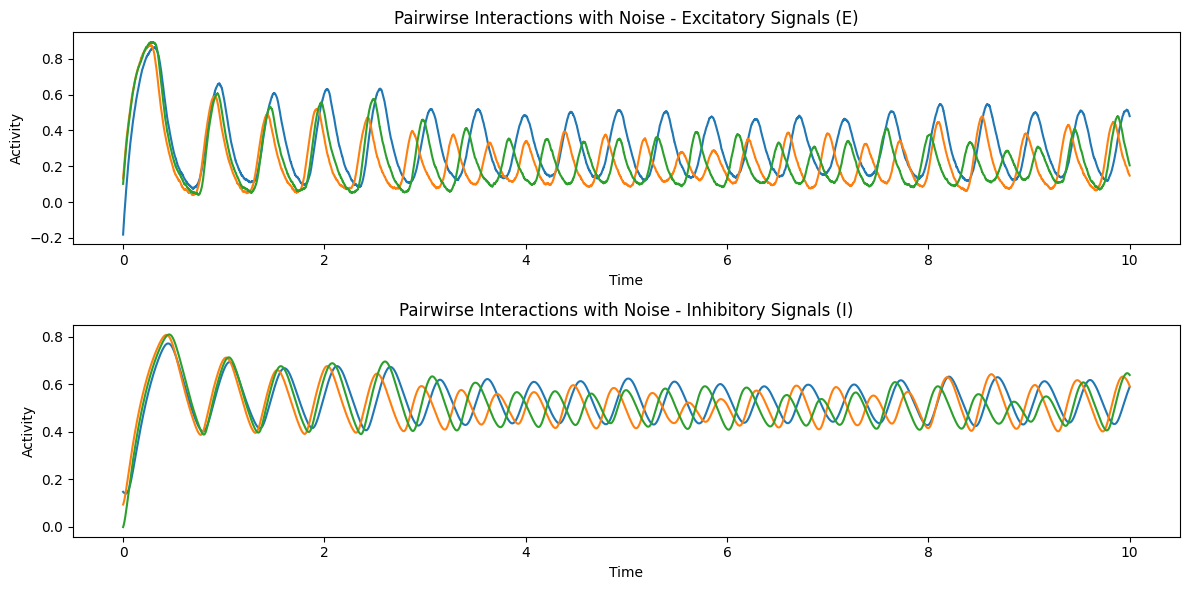

Total timesteps: 10000
Analysis timesteps: 9001

Node 0:
  E: mean=0.2998, std=0.1417, range=[0.0828, 0.6326]
  I: mean=0.5307, std=0.0709, range=[0.4070, 0.6940]

Node 1:
  E: mean=0.2121, std=0.1106, range=[0.0494, 0.5198]
  I: mean=0.5131, std=0.0707, range=[0.3916, 0.7130]

Node 2:
  E: mean=0.2150, std=0.1148, range=[0.0522, 0.5762]
  I: mean=0.5146, std=0.0733, range=[0.3909, 0.7140]


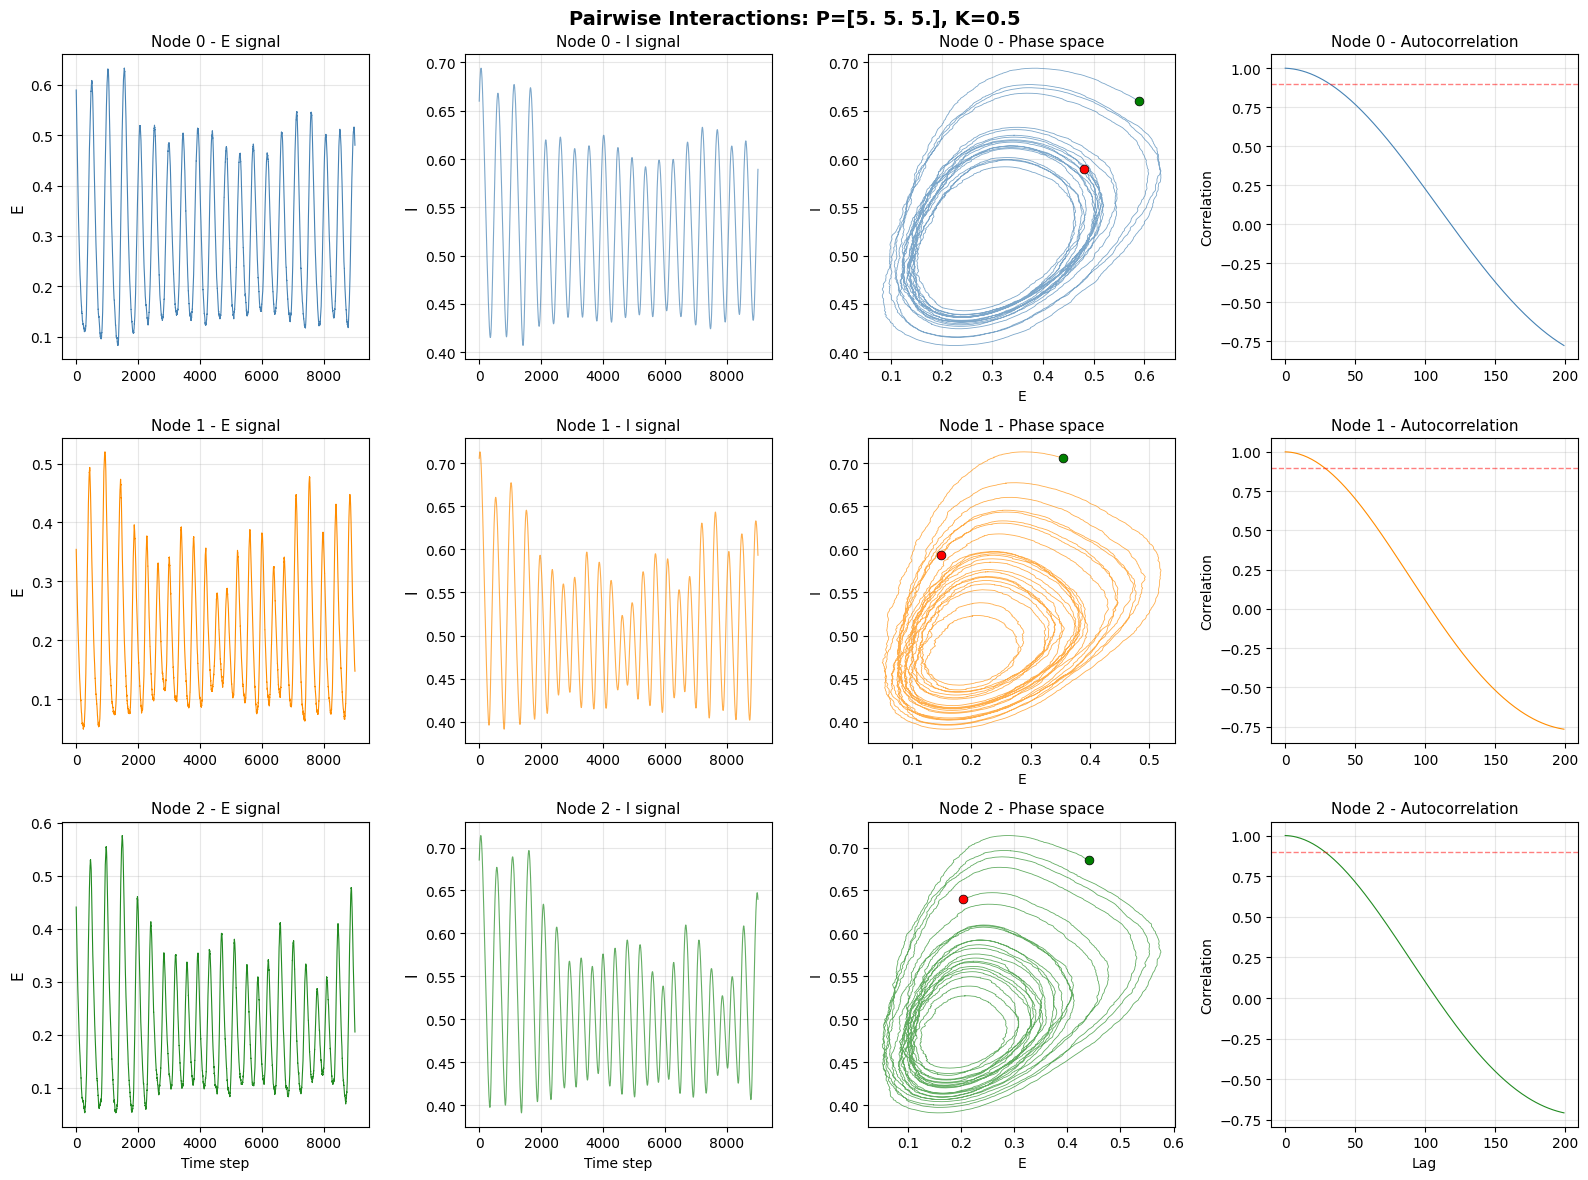

In [18]:
# Simulation parameters with noise
P_sim = np.array([5.0, 5.0, 5.0])  # P por nodo
#P_sim = np.array([-0.5, -0.3999, -0.5])  # P por nodo
K_sim = 0.5

# Initial state
state0 = 0.1 * np.random.randn(2 * N_nodes)
T=10
sigma_E = 0.03

# Simulation with noise using the existing function
t, states = simulate_wc_stochastic(state0, P_sim, K_sim, M, T, dt, higher_order=False, sigma_E = sigma_E)
#t, states = simulate_wc_stochastic_scaled(state0, P_sim, K_sim, M, T, dt, higher_order=False, sigma_E = sigma_E, N_pop=1000)

# Extract signals
E = states[:, :N_nodes]
I = states[:, N_nodes:]

# Visualization using the existing function
plot_signals(t, E, I, title="Pairwirse Interactions with Noise")
# Visualization using the existing function
plot_detailed_signals(t, states, N_nodes, P_sim=P_sim, K_sim=K_sim, title="Pairwise Interactions")


---
## **7. Oscillation Detection in $(P \times K$) Space** with noise
We perform a parameter sweep to detect oscillations in the $(P \times K$) space.


In [ ]:
# Matrix to store oscillation detection
oscillation_map_noise = np.zeros((len(P_values), len(K_values)), dtype=int)

# Matrices to store metrics with noise
TC_map_noise = np.zeros((len(P_values), len(K_values)))
DTC_map_noise = np.zeros((len(P_values), len(K_values)))
Cumulant_map_noise = np.zeros((len(P_values), len(K_values)))
PowerCorr_map_noise = np.zeros((len(P_values), len(K_values)))
Entropy_map_noise = np.zeros((len(P_values), len(K_values)))  # Nueva métrica
Entropy_map_skew = np.zeros((len(P_values), len(K3_values)))  # Nueva métrica
Entropy_map_kurt = np.zeros((len(P_values), len(K3_values)))  # Nueva métrica


P_values = np.linspace(0.0, 10.0, 20)
K_values = np.linspace(0.0, 1.0, 20)
K3_values = np.linspace(0.0, 1.0, 20)
sigma_E = 0.03
#T=150 # 2 minutes
T=375

#initial state
seed = 42
rng = np.random.default_rng(seed)
state0 = 0.1 * rng.standard_normal(2 * N_nodes)



for i, P_val in enumerate(P_values):
    for j, K_val in enumerate(K_values):
        # Simulation with noise using the existing function
        # t, states = simulate_wc_stochastic(state0, P_val, K_val, M, T, dt, sigma_E=sigma_E, higher_order=False)
        P_vec = np.array([P_val, P_val, P_val])
        t, states = simulate_wc_stochastic(state0, P_vec, K_val, M, T, dt, sigma_E = sigma_E, higher_order=False)

        start_idx = int(0.2 * len(t))
        E_node = states[start_idx:, :N_nodes]
        I_node = states[start_idx:, N_nodes:]

        # Oscillation detection using the existing function
        is_lc1, _, _, _ = detect_limit_cycle_poincare(E_node[:, 0], I_node[:, 0], dt, threshold_ratio=0.05, period_cv_threshold=0.05)
        is_lc2, _, _, _ = detect_limit_cycle_poincare(E_node[:, 0], I_node[:, 0], dt, threshold_ratio=0.05, period_cv_threshold=0.05)
        is_lc3, _, _, _ = detect_limit_cycle_poincare(E_node[:, 0], I_node[:, 0], dt, threshold_ratio=0.05, period_cv_threshold=0.05)
        oscillation_map_noise[i, j] =  int((is_lc1==True) and (is_lc2==True) and (is_lc3==True))

        
        # Remove transient
        E = states[start_idx:, :N_nodes]

        # Data matrix for higher-order metrics
        X = E.copy()

        # Covariance matrix
        Sigma = np.cov(X.T)

        # Higher-order metrics using the existing functions
        TC_map_noise[i, j] = TC_gauss(Sigma)
        DTC_map_noise[i, j] = DTC_gauss(Sigma)
        Entropy_map_noise[i, j] = entropy_gauss(Sigma)  # Cálculo de la entropía
        skew, kurt = dev_gauss(X)  # Cálculo de la entropía
        Entropy_map_skew[i, j] = skew
        Entropy_map_kurt[i, j] = kurt
        if X.shape[1] == 3:
            Cumulant_map_noise[i, j] = cumulants(X)
            PowerCorr_map_noise[i, j] = powercorr(X)

    if (i + 1) % 5 == 0:
        print(f"Progress: {i+1}/{len(P_values)}")

# Visualization using the existing function
# plot_oscillation_map(oscillation_map_noise, P_values, K_values, title="Oscillation Detection (P-K) with Noise")


#cleaing the matrix
TC_clean = clean_rowwise_signed(TC_map_noise, n_std=2)
DTC_clean = clean_rowwise_signed(DTC_map_noise, n_std=2)
Cumulant_clean = clean_rowwise_signed(Cumulant_map_noise,n_std=2)
PowerCorr_clean = clean_rowwise_signed(PowerCorr_map_noise,n_std=2)
Skew_clean = clean_rowwise_signed(Entropy_map_skew,n_std=2)
Kurt_clean = clean_rowwise_signed(Entropy_map_kurt,n_std=2)

# visualization the matrix cleaned
plot_metrics_contour(oscillation_map_noise, P_values, K3_values, title="Oscilation detection")

plot_metrics_contour(TC_clean, P_values, K3_values, title="Total Correlation (TC) witht Noise")
plot_metrics_contour(DTC_clean, P_values, K3_values, title="Dual Total Correlation (DTC) witht Noise")
plot_metrics_contour(Cumulant_clean, P_values, K3_values, title="Third-Order Cumulant witht Noise")
plot_metrics_contour(PowerCorr_clean, P_values, K3_values, title="Triple Power Correlation witht Noise")
plot_metrics_contour(Skew_clean, P_values, K3_values, title="skew with Noise")
plot_metrics_contour(Kurt_clean, P_values, K3_values, title="Kurt with Noise")


#os.makedirs("results", exist_ok=True)
np.savez_compressed(
    "../results/metrics_Pairwise_noise.npz",
    oscillation_map=oscillation_map_noise,
    TC=TC_clean,
    DTC=DTC_clean,
    cumulant=Cumulant_clean,
    powercorr=PowerCorr_clean,
    skew=Skew_clean,
    kurt=Kurt_clean,
    P=P_values,
    K3=K3_values
)

Progress: 5/20
Progress: 10/20
Progress: 15/20
Progress: 20/20


NameError: name 'os' is not defined

In [6]:
import os
#os.makedirs("results", exist_ok=True)
np.savez_compressed(
    "../results/metrics_Pairwise_noise.npz",
    oscillation_map=oscillation_map_noise,
    TC=TC_clean,
    DTC=DTC_clean,
    cumulant=Cumulant_clean,
    powercorr=PowerCorr_clean,
    skew=Skew_clean,
    kurt=Kurt_clean,
    P=P_values,
    K3=K3_values
)

In [4]:
import plotly.graph_objects as go
import numpy as np

def plot_metrics_contour(matrix, P_values, K_values, title="Metric Map",
                         colorscale="Inferno", n_contours=15, horizontal_lines=False,P1=0,P2=0):

    z_min = np.nanmin(matrix)
    z_max = np.nanmax(matrix)

    fig = go.Figure(data=go.Contour(
        z=matrix,
        x=K_values,
        y=P_values,
        colorscale=colorscale,
        contours=dict(
            start=z_min,
            end=z_max,
            size=(z_max - z_min) / n_contours,
            coloring='heatmap',
            showlines=True
        ),
        colorbar=dict(
            thickness=12,
            len=0.8
        )
    ))

    if horizontal_lines:
        # líneas horizontales
        fig.add_hline(y=P1, line=dict(color="lightblue", width=3), line_dash="dash")
        fig.add_hline(y=P2, line=dict(color="lightblue", width=3), line_dash="dash")
    
    fig.update_layout(
        title=title,
        xaxis_title='K',
        yaxis_title='P',
        width=500,
        height=400,
        margin=dict(l=60, r=40, t=50, b=50)
    )

    fig.show()

metrics = ["oscillation_map","TC","DTC","cumulant","powercorr","skew","kurt"]
pairwise = np.load("../results/metrics_Pairwise_noise.npz")
for m in metrics:
    plot_metrics_contour(pairwise[m], pairwise["P"], pairwise["K3"], title=f"{m} with Noise",horizontal_lines=True,P1=5,P2=9)